In [1]:
#=
Mean-field EOM (Δc=Δs=0), with correct ordering:
    dα/dt = -(κ/2) α - i g s + ε
    ds/dt = i 2 g α s_z + (Γ - R) s_z s - (Γ+R)/2 s
    ds_z/dt = i g (α* s - α s*) + (R - Γ)|s|^2 - 2 R s_z
Note: i g (α* s - α s*) = -2 g Im(α* s)   ← important sign
This is strict first-order factorization; it can leave the physical manifold for strong drives.
=#

using DifferentialEquations
using PyPlot

struct Params
    g::Float64
    κ::Float64
    Γ::Float64
    R::Float64
    ε::ComplexF64
    S::Float64   # used only for a simple necessary spin-length check
end

function eom!(du,u,p,t)
    αr, αi, sr, si, sz = u
    α = complex(αr, αi)
    s = complex(sr, si)
    abs2s = sr^2 + si^2

    dα  = -(p.κ/2)*α - 1im*p.g*s + p.ε
    ds  =  1im*2*p.g*α*sz + (p.Γ - p.R)*sz*s - 0.5*(p.Γ + p.R)*s
    dsz = -2*p.g*imag(conj(α)*s) + (p.R - p.Γ)*abs2s - 2*p.R*sz

    du[1] = real(dα); du[2] = imag(dα)
    du[3] = real(ds); du[4] = imag(ds)
    du[5] = dsz
    nothing
end

"""
    solve_spin_cavity(p::Params; α0=0+0im, s0=0+0im, sz0=-p.S,
                      tspan=(0.0, 50.0), reltol=1e-9, abstol=1e-12)

Integrate the mean-field equations. Returns (sol, bound_violations) where
`bound_violations` checks the necessary condition |⟨S⃗⟩|^2 = |s|^2 + s_z^2 ≤ S^2.
"""
function solve_spin_cavity(p::Params; α0=0+0im, s0=0+0im, sz0=-p.S,
                           tspan=(0.0, 50.0), reltol=1e-9, abstol=1e-12)
    u0 = [real(α0), imag(α0), real(s0), imag(s0), float(sz0)]
    prob = ODEProblem(eom!, u0, tspan, p)
    sol = solve(prob, Rodas5P(), reltol=reltol, abstol=abstol)

    viol = map(t -> begin
            u = sol(t); sr, si, sz = u[3], u[4], u[5]
            (sr^2 + si^2 + sz^2) - p.S^2
        end, sol.t)
    return sol, viol
end

# --------------------------- Example usage ---------------------------
# using Pkg; Pkg.add(["DifferentialEquations"])

# Physical-ish parameters (ħ=1):
p = Params(0.2, 1.5, 0.04, 0.1, 0.001 + 0.0im, 100.0)

α0 = 0.0 + 0.0im
s0 = 0.0 + 0.0im
sz0 = -p.S

sol, viol = solve_spin_cavity(p; α0, s0, sz0, tspan=(0.0, 100.0))

(ODESolution{Float64, 2, Vector{Vector{Float64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Vector{Float64}}}, Nothing, ODEProblem{Vector{Float64}, Tuple{Float64, Float64}, true, Params, ODEFunction{true, SciMLBase.AutoSpecialize, FunctionWrappersWrappers.FunctionWrappersWrapper{Tuple{FunctionWrappers.FunctionWrapper{Nothing, Tuple{Vector{Float64}, Vector{Float64}, Params, Float64}}, FunctionWrappers.FunctionWrapper{Nothing, Tuple{Vector{ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}, Vector{ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}, Params, Float64}}, FunctionWrappers.FunctionWrapper{Nothing, Tuple{Vector{ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}, Vector{Float64}, Params, ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBase.OrdinaryDiffEqTag, Float64}, Float64, 1}}}, FunctionWrappers.FunctionWrapper{Nothing, Tuple{Vector{ForwardDiff.Dual{ForwardDiff.Tag{DiffEqBa

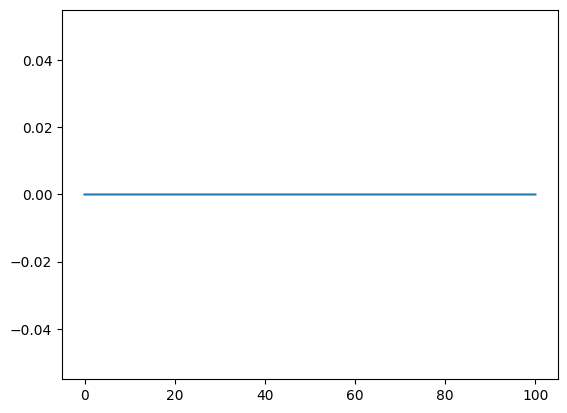

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x31d0425d0>

In [2]:
#plot(sol.t, map(x-> x[5], sol.u))
plot(sol.t, map(x-> abs(x[3]), sol.u))

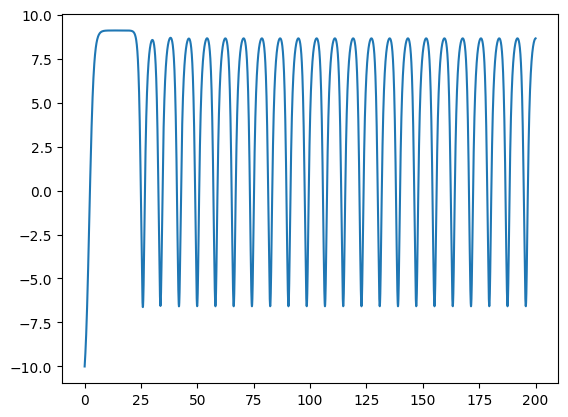

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x31d359a90>

In [3]:
#=
EOM with spin-length closure (⟨S_z^2⟩ ≈ s_z^2) and commutator-consistent mixed products:
    dα/dt = -(κ/2) α - i g s + ε
    ds/dt = i 2 g α s_z + (Γ - R) s_z s - (Γ+R)/2 s
    ds_z/dt = -2 g Im(α* s) + (R - Γ)[S(S+1) - s_z^2] - (Γ+R) s_z
=#

using DifferentialEquations

struct Params
    g::Float64
    κ::Float64
    Γ::Float64
    R::Float64
    ε::ComplexF64
    S::Float64
end

function eom!(du,u,p,t)
    αr, αi, sr, si, sz = u
    α = complex(αr, αi)
    s = complex(sr, si)

    dα  = -(p.κ/2)*α - 1im*p.g*s + p.ε
    ds  =  1im*2*p.g*α*sz + (p.Γ - p.R)*sz*s - 0.5*(p.Γ + p.R)*s
    dsz = -2*p.g*imag(conj(α)*s) + (p.R - p.Γ)*(p.S*(p.S+1) - sz^2) - (p.Γ + p.R)*sz

    du[1] = real(dα); du[2] = imag(dα)
    du[3] = real(ds); du[4] = imag(ds)
    du[5] = dsz
    nothing
end

"""
    solve_spin_cavity(p::Params; α0=0+0im, s0=0+0im, sz0=-p.S,
                      tspan=(0.0, 100.0), reltol=1e-9, abstol=1e-12)

Integrate the mean-field equations and return the solution object.
"""
function solve_spin_cavity(p::Params; α0=0+0im, s0=0+0im, sz0=-p.S,
                           tspan=(0.0, 100.0), reltol=1e-9, abstol=1e-12)
    u0 = [real(α0), imag(α0), real(s0), imag(s0), float(sz0)]
    prob = ODEProblem(eom!, u0, tspan, p)
    solve(prob, Rodas5P(); reltol, abstol)
end

function eom_ss!(du,u,p,t)
    sr, si, sz = u
    s = complex(sr, si)

    α  = (- 1im*p.g*s + p.ε) / (p.κ/2)
    ds  =  1im*2*p.g*α*sz + (p.Γ - p.R)*sz*s - 0.5*(p.Γ + p.R)*s
    dsz = -2*p.g*imag(conj(α)*s) + (p.R - p.Γ)*(p.S*(p.S+1) - sz^2) - (p.Γ + p.R)*sz

    du[1] = real(ds); du[2] = imag(ds)
    du[3] = dsz
    nothing
end

"""
    solve_spin_cavity(p::Params; α0=0+0im, s0=0+0im, sz0=-p.S,
                      tspan=(0.0, 100.0), reltol=1e-9, abstol=1e-12)

Integrate the mean-field equations and return the solution object.
"""
function solve_spin_cavity_ss(p::Params; s0=0+0im, sz0=-p.S,
                           tspan=(0.0, 100.0), reltol=1e-9, abstol=1e-12)
    u0 = [real(s0), imag(s0), float(sz0)]
    prob = ODEProblem(eom_ss!, u0, tspan, p)
    solve(prob, Rodas5P(); reltol, abstol)
end

# --------------------------- Example usage ---------------------------
# using Pkg; Pkg.add(["DifferentialEquations"])

p = Params(0.3, 1.0, 0.05, 0.10, 0.000001 + 0.00im, 10.0)

α0 = 0.0 + 0.0im
s0 = 0.0 + 0.0im
sz0 = -p.S

sol = solve_spin_cavity(p; α0, s0, sz0, tspan=(0.0, 200.0))
plot(sol.t, map(x-> x[5], sol.u))

#sol = solve_spin_cavity_ss(p; s0, sz0, tspan=(0.0, 200.0))
#plot(sol.t, map(x-> x[2], sol.u))


In [4]:
using QuantumOptics

# --- params container ---------------------------------------------------------
Base.@kwdef struct ParamsFull
    S::Rational{Int}   # e.g. 1//2, 1//1, 3//2
    Ncav::Int          # Fock cutoff
    g::Float64         # spin-cavity coupling
    κ::Float64         # cavity decay rate
    Γ::Float64         # spin decay rate (S⁻)
    R::Float64         # spin pump rate (S⁺)
    ϵ::ComplexF64      # coherent cavity drive amplitude
end

# --- build Hilbert space, ops, H, jumps --------------------------------------
function build_model(p::ParamsFull)
    bc = FockBasis(p.Ncav)
    bs = SpinBasis(p.S)                      # arbitrary spin (half-integer OK)
    a  = destroy(bc);  ad = create(bc)
    Sp = sigmap(bs);  Sm = sigmam(bs)
    Sz = 0.5*sigmaz(bs)                      # ensure [Sz,Sm] = -Sm (our convention)

    onec = identityoperator(bc)
    ones = identityoperator(bs)

    # Hamiltonian in the rotating frame at the drive (Δc=Δs=0):
    # H = g (a S⁺ + a† S⁻) + i(ϵ a† - ϵ* a)
    H =  p.g*(tensor(a,Sp) + tensor(ad,Sm)) +
         1im*( p.ϵ*tensor(ad,ones) - conj(p.ϵ)*tensor(a,ones) )

    # Collapse operators: √κ a, √Γ S⁻, √R S⁺
    J =[sqrt(p.κ)*tensor(a,ones),
        sqrt(p.Γ)*tensor(onec,Sm),
        sqrt(p.R)*tensor(onec,Sp)]

    # Observables of interest
    A  = tensor(a,ones)          # cavity field
    Sm_full = tensor(onec,Sm)    # spin lowering
    Sz_full = tensor(onec,Sz)    # spin inversion (our S_z)

    return (bc, bs, H, J, A, Sm_full, Sz_full)
end

# --- initial state ------------------------------------------------------------
function initial_state(bc, bs; α0=0.0+0.0im, m0=:down)
    ψc = abs(α0) > 0 ? coherentstate(bc, α0) : fockstate(bc, 0)

    if m0 == :up
        ψs = spinup(bs)
    elseif m0 == :down
        ψs = spindown(bs)
    else
        error("spin_state must be :up or :down")
    end

    return ψc ⊗ ψs
end

# --- time evolution -----------------------------------------------------------
"""
    simulate(p; T=200.0, dt=0.1, α0=0+0im, m0=:down)

Return (t, ρt, obs) where obs is a NamedTuple with ⟨a⟩, ⟨S⁻⟩, ⟨S_z⟩, n̄=⟨a†a⟩.
"""
function simulate(p::ParamsFull; T=200.0, dt=0.1, α0=0+0im, m0=:down)
    bc, bs, H, J, A, Sm_full, Sz_full = build_model(p)
    ψ0 = initial_state(bc, bs; α0, m0)
    t = collect(0:dt:T)

    tout, ρt = timeevolution.master(t, ψ0, H, J)  # Lindblad MEQ (time-independent) :contentReference[oaicite:0]{index=0}

    αt  = expect(A,    ρt)                        # ⟨a⟩(t)
    st  = expect(Sm_full, ρt)                     # ⟨S⁻⟩(t)
    szt = real(expect(Sz_full, ρt))               # ⟨S_z⟩(t)
    nb  = real(expect(number(bc)⊗identityoperator(bs), ρt))  # photon number

    return tout, ρt, (a=αt, s=st, sz=szt, nbar=nb)
end

# --- steady state helper (optional) ------------------------------------------
"""
    steady_state(p; α0=0+0im, m0=:down, tol=1e-6)

Compute steady state ρ_ss and its observables using the time-evolution based solver.
"""
function steady_state(p::ParamsFull; α0=0+0im, m0=:down, tol=1e-6)
    bc, bs, H, J, A, Sm_full, Sz_full = build_model(p)
    ψ0 = initial_state(bc, bs; α0, m0)
    tout, ρlist = steadystate.master(H, J; ψ0, tol)         # :contentReference[oaicite:1]{index=1}
    ρss = ρlist[end]
    αss = expect(A, ρlist)
    sss = expect(Sm_full, ρlist)
    szss= real(expect(Sz_full, ρlist))
    nss = real(expect(number(bc)⊗identityoperator(bs), ρlist))
    return ρss, (a=αss, s=sss, sz=szss, nbar=nss)
end

# ---------------------------- example usage ----------------------------------
# using Pkg; Pkg.add(["QuantumOptics"])
p = ParamsFull(10//1, 10, 0.3, 1.0, 0.05, 0.10, 0.000001 + 0.00im)

t, ρt, obs = simulate(p; T=200.0, dt=0.2, α0=0+0im, m0=:down)


([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8  …  198.2, 198.4, 198.6, 198.8, 199.0, 199.2, 199.4, 199.6, 199.8, 200.0], Operator{CompositeBasis{Vector{Int64}, Tuple{FockBasis{Int64}, SpinBasis{10//1, Int64}}}, CompositeBasis{Vector{Int64}, Tuple{FockBasis{Int64}, SpinBasis{10//1, Int64}}}, Matrix{ComplexF64}}[Operator(dim=231x231)
  basis: [Fock(cutoff=10) ⊗ Spin(10)]
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0

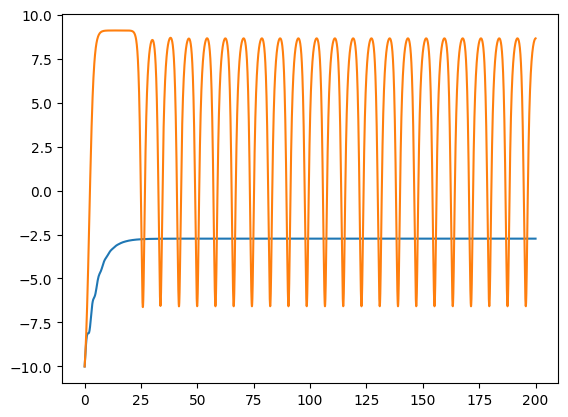

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x31f65f110>

In [5]:
plot(t, obs[:sz])
plot(sol.t, map(x-> x[5], sol.u))

In [6]:
###########################
# Mean-field (κ → large)  #
###########################
using DifferentialEquations

struct ParamsMF
    g::Float64; κ::Float64; Γ::Float64; R::Float64; ε::ComplexF64; S::Float64
end

"""
EOM (Δc=Δs=0), α eliminated: α = (2/κ)(ε - i g s)
    ds/dt   = i 2 g α s_z + (Γ - R) s_z s - (Γ+R)/2 s
    ds_z/dt = -2 g Im(α* s) + (R - Γ)[S(S+1) - s_z^2] - (Γ+R) s_z
"""
function eom_mf_elim!(du,u,p::ParamsMF,t)
    sr, si, sz = u
    s  = complex(sr, si)
    α  = (2/p.κ)*(p.ε - 1im*p.g*s)

    ds  =  1im*2*p.g*α*sz + (p.Γ - p.R)*sz*s - 0.5*(p.Γ + p.R)*s
    dsz = -2*p.g*imag(conj(α)*s) + (p.R - p.Γ)*(p.S*(p.S+1) - sz^2) - (p.Γ + p.R)*sz

    du[1] = real(ds); du[2] = imag(ds); du[3] = dsz
end

function solve_mf_elim(p::ParamsMF; s0=0+0im, sz0=-p.S, tspan=(0.0,200.0), reltol=1e-9, abstol=1e-12)
    u0 = [real(s0), imag(s0), float(sz0)]
    prob = ODEProblem(eom_mf_elim!, u0, tspan, p)
    solve(prob, Rodas5P(); reltol, abstol)
end

##############################################
# Full quantum, cavity adiabatically eliminated
# Spin-only Lindblad with Ω = (2g/κ)ε, C=4g^2/κ
##############################################
using QuantumOptics

Base.@kwdef struct ParamsSpinOnly
    S::Rational{Int}   # e.g., 1//2, 1//1, 3//2, ...
    Γ::Float64         # bare spin decay (S⁻)
    R::Float64         # spin pump (S⁺)
    Ω::ComplexF64      # effective coherent drive on spin (Ω S⁺ + Ω* S⁻)
    C::Float64         # Purcell (extra) decay rate from cavity elim
end

function build_spinonly(p::ParamsSpinOnly)
    bs = SpinBasis(p.S)
    Sp, Sm = sigmap(bs), sigmam(bs)
    Sz     = 0.5*sigmaz(bs)       # [Sz,Sm] = -Sm

    # H_eff = Ω S⁺ + Ω* S⁻   (Δ=0, so no dispersive shift kept)
    H = p.Ω*Sp + conj(p.Ω)*Sm

    # Jumps: √(Γ+C) S⁻, √R S⁺
    J = [sqrt(p.Γ + p.C)*Sm, sqrt(p.R)*Sp]

    return (bs, H, J, Sp, Sm, Sz)
end

"""
Time-evolve the spin-only master equation.
Returns (t, ρt, obs) with obs having ⟨S⁻⟩ and ⟨S_z⟩.
"""
function simulate_spinonly(p::ParamsSpinOnly; T=200.0, dt=0.2, spin_state=:down)
    bs, H, J, Sp, Sm, Sz = build_spinonly(p)
    ψs = spin_state==:up ? spinup(bs) : spindown(bs)
    t = 0:dt:T
    tout, ρt = timeevolution.master(t, ψs, H, J)
    return tout, ρt, (s=expect(Sm, ρt), sz=real(expect(Sz, ρt)))
end

"""
Steady state of the spin-only model.
"""
function steadystate_spinonly(p::ParamsSpinOnly)
    bs, H, J, Sp, Sm, Sz = build_spinonly(p)
    ρss = steadystate.master(H, J)
    return ρss, (s=expect(Sm, ρss), sz=real(expect(Sz, ρss)))
end

##########################
# Convenience wrappers   #
##########################

"""
Given original (g, κ, ε), compute Ω=(2g/κ)ε and C=4g^2/κ.
"""
spinonly_params_from_cavity(S::Rational, Γ, R, g, κ, ε) = ParamsSpinOnly(S=S, Γ=Γ, R=R, Ω=(2g/κ)*ε, C=4g^2/κ)

# ---------------------- Example usage ----------------------
# using Pkg; Pkg.add(["DifferentialEquations","QuantumOptics"])

# Physical-ish parameters
g, κ = 1e-2, 4.0              # bad cavity: κ ≫ g
Γ, R = 0.0, 0.65 * 4 * g ^ 2 / κ
ε    = 0.0001 + 0im
Sspin= 25//1                   # exact spin (rational)
Sbig = Float64(Sspin)                    # mean-field S (float)
Tmax = 20000.0


# Mean-field (with α eliminated)
pmf = ParamsMF(g, κ, Γ, R, ε, Sbig)
sol_mf = solve_mf_elim(pmf; s0=0+0im, sz0=-Sbig, tspan=(0.0, Tmax))
pspin = spinonly_params_from_cavity(Sspin, Γ, R, g, κ, ε)
tq, ρt, obs = simulate_spinonly(pspin; T=Tmax, dt=0.2, spin_state=:down);


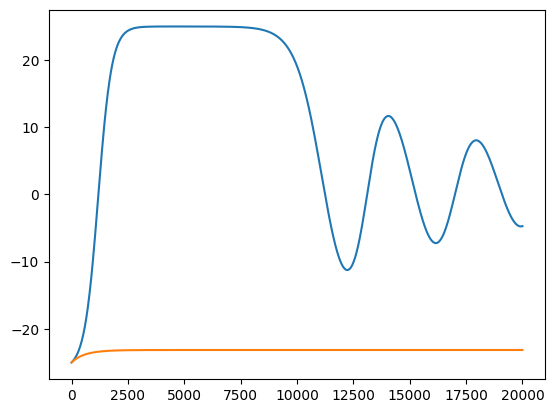

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x31f6d3d90>

In [7]:
# extract mean-field s_z trajectory
t_mf  = sol_mf.t
sz_mf = [u[3] for u in sol_mf.u]

# extract quantum s_z trajectory
t_q   = tq
sz_q  = obs.sz

plot(t_mf, sz_mf, label="mean-field")
plot(t_q, sz_q, label="quantum (spin-only)")


/Users/nicobassler/.pyenv/versions/pyloc/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/nicobassler/.pyenv/versions/pyloc/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


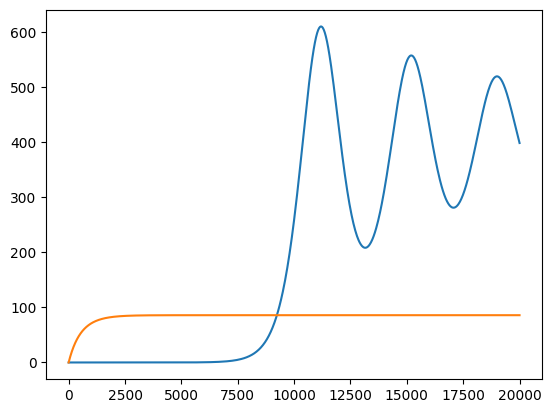

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x33f16ec10>

In [8]:
# Mean-field ⟨S⁺S⁻⟩ ≈ |s|^2
s_mf   = [complex(u[1], u[2]) for u in sol_mf.u]  # (sr, si)
ss_mf  = abs2.(s_mf)                              # |s|^2

# Quantum ⟨S⁺S⁻⟩
bs, H, J, Sp, Sm, Sz = build_spinonly(pspin)
ss_q = expect(Sp*Sm, ρt)

# Plot both
plot(t_mf, ss_mf, label="mean-field ⟨S⁺S⁻⟩")
plot(t_q, ss_q, label="quantum ⟨S⁺S⁻⟩")


In [9]:
# ---------- 2nd-order mean-field (spin-only, κ ≫ g) ----------
using DifferentialEquations

Base.@kwdef struct ParamsSpin2
    S::Float64          # spin length (float)
    Γt::Float64         # total decay = Γ + 4g^2/κ (Purcell included)
    R::Float64          # pump
    Ω::ComplexF64       # coherent spin drive = (2g/κ) ε
end

# u = [sr, si, sz, v] with s = sr + i si, v = ⟨S_z^2⟩
function eom_spinonly_2nd!(du,u,p::ParamsSpin2,t)
    sr, si, sz, v = u
    s = complex(sr, si)
    S, Γt, R, Ω = p.S, p.Γt, p.R, p.Ω

    # identities
    SpSm = S*(S+1) - v + sz
    SmSp = S*(S+1) - v - sz

    # ds/dt
    ds  = 1im*2*Ω*sz + (Γt - R)*sz*s - 0.5*(Γt + R)*s
    # dsz/dt
    dsz = -2*imag(conj(Ω)*s) + (R - Γt)*(S*(S+1) - v) - (Γt + R)*sz
    # dv/dt = coherent + dissipative
    dv_coh  = -4*imag(conj(Ω)*(sz*s)) + 4*imag(conj(Ω)*s)
    dv_diss = Γt*(-2*sz + 1)*SpSm + R*(2*sz + 1)*SmSp
    dv = dv_coh + dv_diss

    du[1]=real(ds); du[2]=imag(ds); du[3]=dsz; du[4]=dv
end

function simulate_spinonly_mf2(p::ParamsSpin2; s0=0+0im, sz0=-p.S, v0= p.S^2, tspan=(0.0,6000.0))
    u0 = [real(s0), imag(s0), float(sz0), float(v0)]
    prob = ODEProblem(eom_spinonly_2nd!, u0, tspan, p)
    solve(prob, Rodas5P(); reltol=1e-9, abstol=1e-12)
end

# helpful observable from the 2nd-order closure:
SplusSminus_from_state(u, S) = S*(S+1) - u[4] + u[3]   # = ⟨S⁺S⁻⟩

# ---------- full spin-only quantum (κ ≫ g) ----------
using QuantumOptics

Base.@kwdef struct ParamsSpinOnly
    S::Rational{Int}; Γ::Float64; R::Float64; Ω::ComplexF64; C::Float64
end

spinonly_params_from_cavity(S::Rational, Γ, R, g, κ, ε) = ParamsSpinOnly(
    S=S, Γ=Γ, R=R, Ω=(2g/κ)*ε, C=4g^2/κ)

function build_spinonly(p::ParamsSpinOnly)
    bs = SpinBasis(p.S)
    Sp, Sm = sigmap(bs), sigmam(bs)
    Sz = 0.5*sigmaz(bs)
    H  = p.Ω*Sp + conj(p.Ω)*Sm
    J  = [sqrt(p.Γ+p.C)*Sm, sqrt(p.R)*Sp]
    return bs, H, J, Sp, Sm, Sz
end

function simulate_spinonly(p::ParamsSpinOnly; T=6000.0, dt=0.2, spin_state=:down)
    bs, H, J, Sp, Sm, Sz = build_spinonly(p)
    ψs = spin_state==:up ? spinup(bs) : spindown(bs)
    t = 0:dt:T
    tout, ρt = timeevolution.master(t, ψs, H, J)
    return tout, ρt, (s=expect(Sm,ρt), sz=real(expect(Sz,ρt)), spsm=real(expect(Sp*Sm,ρt)))
end


simulate_spinonly (generic function with 1 method)

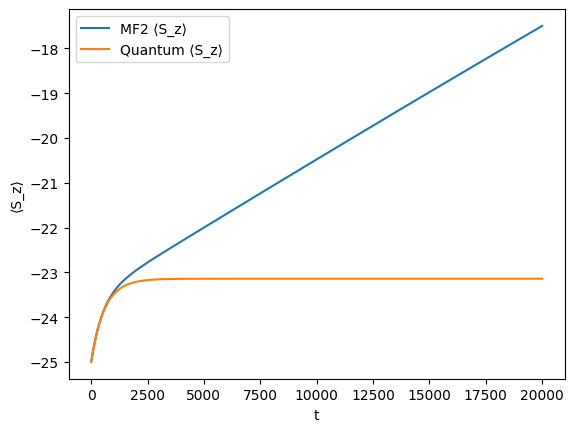

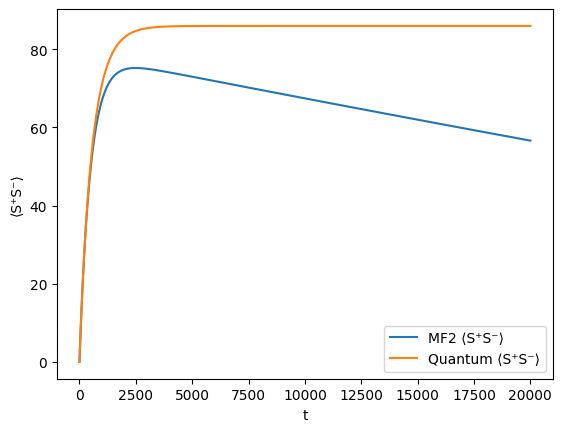

PyObject <matplotlib.legend.Legend object at 0x33f25f110>

In [10]:
# Mean-field (2nd order, cavity eliminated)
Ω = (2g/κ)*ε
Γt = Γ + 4g^2/κ
pmf2 = ParamsSpin2(S=Sbig, Γt=Γt, R=R, Ω=Ω)
sol_mf2 = simulate_spinonly_mf2(pmf2; s0=0+0im, sz0=-Sbig, v0=Sbig^2, tspan=(0.0,Tmax))

# Full quantum (spin-only)
pspin = spinonly_params_from_cavity(Sspin, Γ, R, g, κ, ε)
tq, ρt, obs = simulate_spinonly(pspin; T=Tmax, dt=0.2, spin_state=:down)

tmf   = sol_mf2.t
sz_mf = [u[3] for u in sol_mf2.u]
ss_mf = [SplusSminus_from_state(u, Sbig) for u in sol_mf2.u]

# extract quantum observables
tq   = tq
sz_q = obs.sz
ss_q = obs.spsm

figure()
plot(tmf, sz_mf, label="MF2 ⟨S_z⟩")
plot(tq,  sz_q,  label="Quantum ⟨S_z⟩")
xlabel("t"); ylabel("⟨S_z⟩")
legend()

figure()
plot(tmf, ss_mf, label="MF2 ⟨S⁺S⁻⟩")
plot(tq,  ss_q,  label="Quantum ⟨S⁺S⁻⟩")
xlabel("t"); ylabel("⟨S⁺S⁻⟩")
legend()


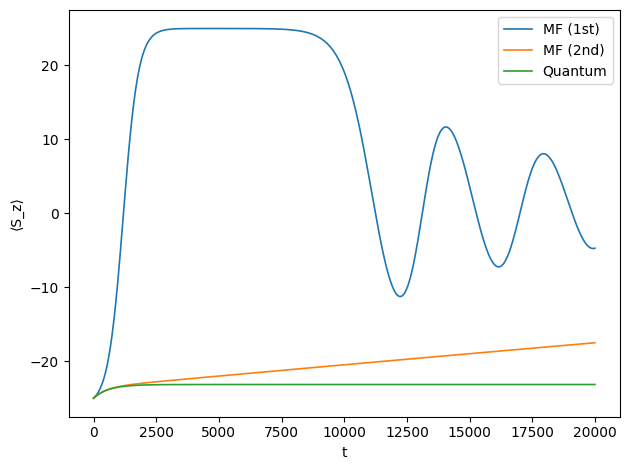

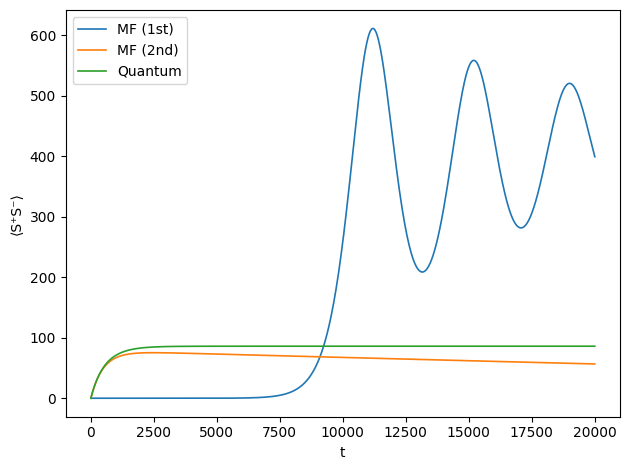

In [11]:
# --- extract trajectories ---
# MF (1st order)
t_mf1  = sol_mf.t
sz_mf1 = [u[3] for u in sol_mf.u]
ss_mf1 = [ (u[1]^2 + u[2]^2) for u in sol_mf.u ]   # ⟨S⁺S⁻⟩ ≈ |s|^2, s = u[1]+i u[2]

# MF (2nd order)
t_mf2  = sol_mf2.t
sz_mf2 = [u[3] for u in sol_mf2.u]
ss_mf2 = [ SplusSminus_from_state(u, Sbig) for u in sol_mf2.u ]  # = S(S+1) - v + s_z

# Quantum (spin-only)
t_q   = tq
sz_q  = obs.sz
ss_q  = obs.spsm

# --- plots ---
figure()
plot(t_mf1, sz_mf1, label="MF (1st)", linewidth=1.2)
plot(t_mf2, sz_mf2, label="MF (2nd)", linewidth=1.2)
plot(t_q,   sz_q,   label="Quantum",  linewidth=1.2)
xlabel("t"); ylabel("⟨S_z⟩"); legend(); tight_layout()

figure()
plot(t_mf1, ss_mf1, label="MF (1st)", linewidth=1.2)
plot(t_mf2, ss_mf2, label="MF (2nd)", linewidth=1.2)
plot(t_q,   ss_q,   label="Quantum",  linewidth=1.2)
xlabel("t"); ylabel("⟨S⁺S⁻⟩"); legend(); tight_layout()
